# Group00 &middot; ds004504 &middot; Task 3a &mdash; Ablation, Final Model & Significance Test
**Track:** 1 &middot; GNN on table-style EEG data &middot; **Notebook:** `task3_improvement_ablation`

One-factor-at-a-time ablation over graph type, GNN architecture, depth and width vs. the Task 2b default config, selection of a final architecture, a **subject-grouped 5-fold CV** comparing it to the best Task 2a baseline, a **paired Wilcoxon signed-rank test**, and a comparison against the related-work benchmark (Liu et al. 2026, DT-GCN — same dataset) from Task 1.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_DIR = Path("/content/drive/MyDrive/EEG_Project_ds004504")
FEATURE_CACHE = DRIVE_DIR / "features_cache.npz"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch

# Install PyTorch Geometric and required dependencies
!pip install -q torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.6/681.6 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import wilcoxon

torch.manual_seed(42); np.random.seed(42)
sns.set_theme(style="whitegrid")
GROUP_ORDER = ["A", "F", "C"]
LABEL_MAP = {g: i for i, g in enumerate(GROUP_ORDER)}

FEATURE_CACHE, DEMO_CACHE = Path("features_cache.npz"), Path("demo_synthetic_features.npz")
cache_path, MODE = (FEATURE_CACHE, "REAL") if FEATURE_CACHE.exists() else (DEMO_CACHE, "DEMO")
cache = np.load(cache_path, allow_pickle=True)
node_feats, corr_adj, plv_adj = cache["node_feats"], cache["corr_adj"], cache["plv_adj"]
group = cache["group"]
y = np.array([LABEL_MAP[g] for g in group])
n_subj, n_ch, n_bands = node_feats.shape
print(f"[MODE={MODE}] {n_subj} subjects loaded from {cache_path}")

with open("baseline_results.json") as f:
    baseline_summary = json.load(f)
train_idx = np.array(baseline_summary["split"]["train"])
val_idx = np.array(baseline_summary["split"]["val"])
test_idx = np.array(baseline_summary["split"]["test"])
best_baseline_name = baseline_summary["best_model"]
best_baseline_f1 = baseline_summary["best_macro_f1"]

with open("gnn_first_result.json") as f:
    first_gnn = json.load(f)
print(f"Task 2a baseline to beat: {best_baseline_name} (macro-F1={best_baseline_f1:.3f})")
print(f"Task 2b first GNN result: macro-F1={first_gnn['test_macro_f1']:.3f}")


[MODE=REAL] 88 subjects loaded from features_cache.npz
Task 2a baseline to beat: SVM-RBF (macro-F1=0.595)
Task 2b first GNN result: macro-F1=0.458


In [ ]:
def build_edge_index_weight(adj, top_k=None):
    n = adj.shape[0]
    a = np.abs(adj.copy()); np.fill_diagonal(a, 0)
    if top_k is not None:
        mask = np.zeros_like(a, dtype=bool)
        for i in range(n):
            mask[i, np.argsort(a[i])[-top_k:]] = True
        mask |= mask.T
        a = a * mask
    src, dst = np.nonzero(a)
    return (torch.tensor(np.stack([src, dst]), dtype=torch.long),
            torch.tensor(a[src, dst], dtype=torch.float))

def make_graph_dataset(node_feats, adj_stack, y, indices, feat_scaler=None, top_k=None):
    out = []
    for i in indices:
        x = node_feats[i]
        if feat_scaler is not None:
            x = feat_scaler.transform(x.reshape(1, -1)).reshape(x.shape)
        ei, ew = build_edge_index_weight(adj_stack[i], top_k=top_k)
        out.append(Data(x=torch.tensor(x, dtype=torch.float), edge_index=ei, edge_attr=ew,
                         y=torch.tensor([y[i]], dtype=torch.long)))
    return out

class EEG_GNN(nn.Module):
    def __init__(self, in_dim, hidden, n_layers, n_classes=3, dropout=0.3, conv_type="gcn"):
        super().__init__()
        Conv = {"gcn": GCNConv, "gat": GATConv, "sage": SAGEConv}[conv_type]
        dims = [in_dim] + [hidden] * n_layers
        self.convs = nn.ModuleList(Conv(a, b) for a, b in zip(dims[:-1], dims[1:]))
        self.conv_type = conv_type
        self.dropout = dropout
        self.lin = nn.Linear(hidden, n_classes)

    def forward(self, x, edge_index, edge_weight, batch):
        for conv in self.convs:
            x = conv(x, edge_index, edge_weight) if self.conv_type == "gcn" else conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin(global_mean_pool(x, batch))

@torch.no_grad()
def evaluate_gnn(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    pred_all, true_all = [], []
    for batch in loader:
        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).argmax(dim=1)
        pred_all += pred.tolist(); true_all += batch.y.tolist()
    return {"accuracy": accuracy_score(true_all, pred_all),
            "macro_f1": f1_score(true_all, pred_all, average="macro"),
            "y_true": true_all, "y_pred": pred_all}

def train_gnn(train_ds, val_ds, hidden=32, n_layers=2, conv_type="gcn", epochs=60, lr=1e-3, class_weight=None):
    model = EEG_GNN(in_dim=n_bands, hidden=hidden, n_layers=n_layers, conv_type=conv_type)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    best_f1, best_state = -1, None
    for _ in range(epochs):
        model.train()
        for batch in loader:
            opt.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            F.cross_entropy(out, batch.y, weight=class_weight).backward()
            opt.step()
        if val_ds:
            f1 = evaluate_gnn(model, val_ds)["macro_f1"]
            if f1 > best_f1:
                best_f1, best_state = f1, {k: v.clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

class_weights = torch.tensor([1.0 / (y[train_idx] == c).sum() for c in range(3)], dtype=torch.float)
class_weights = class_weights / class_weights.sum() * 3
node_scaler = StandardScaler().fit(node_feats[train_idx].reshape(len(train_idx), -1))
print("Helper functions + Task 2b default config ready.")


Helper functions + Task 2b default config ready.


## Ablation: one factor at a time vs. the Task 2b default
Default = correlation graph, 2-layer GCN, hidden=32, class-weighted loss. Each row below changes exactly one factor and reports validation macro-F1 (train/val split from Task 2a — test set is held out untouched until the final CV below).

In [ ]:
ablation_configs = [
    {"label": "Default (corr, GCN, 2L, h32, weighted)", "graph": "corr", "conv": "gcn", "layers": 2, "hidden": 32, "weighted": True},
    {"label": "Graph: PLV instead of correlation",       "graph": "plv",  "conv": "gcn", "layers": 2, "hidden": 32, "weighted": True},
    {"label": "Architecture: GAT",                        "graph": "corr", "conv": "gat", "layers": 2, "hidden": 32, "weighted": True},
    {"label": "Architecture: GraphSAGE",                  "graph": "corr", "conv": "sage","layers": 2, "hidden": 32, "weighted": True},
    {"label": "Depth: 1 layer",                            "graph": "corr", "conv": "gcn", "layers": 1, "hidden": 32, "weighted": True},
    {"label": "Depth: 3 layers",                           "graph": "corr", "conv": "gcn", "layers": 3, "hidden": 32, "weighted": True},
    {"label": "Width: hidden=16",                          "graph": "corr", "conv": "gcn", "layers": 2, "hidden": 16, "weighted": True},
    {"label": "Width: hidden=64",                          "graph": "corr", "conv": "gcn", "layers": 2, "hidden": 64, "weighted": True},
    {"label": "No class weighting",                        "graph": "corr", "conv": "gcn", "layers": 2, "hidden": 32, "weighted": False},
]

ablation_rows = []

for cfg in ablation_configs:

    adj_stack = corr_adj if cfg["graph"] == "corr" else plv_adj

    train_ds = make_graph_dataset(
        node_feats, adj_stack, y, train_idx, node_scaler
    )

    val_ds = make_graph_dataset(
        node_feats, adj_stack, y, val_idx, node_scaler
    )

    cw = class_weights if cfg["weighted"] else None

    model = train_gnn(
        train_ds,
        val_ds,
        hidden=cfg["hidden"],
        n_layers=cfg["layers"],
        conv_type=cfg["conv"],
        class_weight=cw,
        epochs=60
    )


    results = evaluate_gnn(model, val_ds)

    val_f1 = results["macro_f1"]
    val_accuracy = results["accuracy"]

    ablation_rows.append({
        **cfg,
        "val_macro_f1": val_f1,
        "val_accuracy": val_accuracy
    })

    print(
        f"{cfg['label']:42s} "
        f"Macro-F1={val_f1:.3f} | "
        f"Accuracy={val_accuracy:.3f}"
    )

ablation_df = pd.DataFrame(ablation_rows).sort_values(
    "val_macro_f1",
    ascending=False
)


Default (corr, GCN, 2L, h32, weighted)     Macro-F1=0.600 | Accuracy=0.636
Graph: PLV instead of correlation          Macro-F1=0.724 | Accuracy=0.727
Architecture: GAT                          Macro-F1=0.606 | Accuracy=0.636
Architecture: GraphSAGE                    Macro-F1=0.726 | Accuracy=0.727
Depth: 1 layer                             Macro-F1=0.415 | Accuracy=0.545
Depth: 3 layers                            Macro-F1=0.540 | Accuracy=0.545
Width: hidden=16                           Macro-F1=0.739 | Accuracy=0.727
Width: hidden=64                           Macro-F1=0.600 | Accuracy=0.636
No class weighting                         Macro-F1=0.432 | Accuracy=0.545


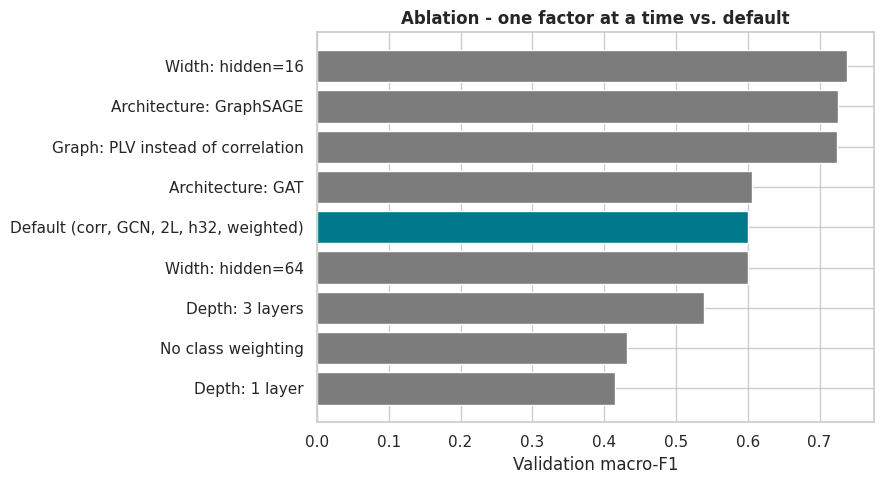


Best config by validation macro-F1: Width: hidden=16


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#00798c" if l.startswith("Default") else "#7c7c7c" for l in ablation_df["label"]]
ax.barh(ablation_df["label"], ablation_df["val_macro_f1"], color=colors)
ax.set_xlabel("Validation macro-F1"); ax.set_title("Ablation - one factor at a time vs. default", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

best_cfg = ablation_df.iloc[0].to_dict()
print("\nBest config by validation macro-F1:", best_cfg["label"])


## Final model: subject-grouped 5-fold CV vs. best baseline
One row = one subject, so `StratifiedKFold` is leakage-safe (equivalent to grouping by `participant_id`, since no subject can appear in two folds when there is exactly one sample per subject). Each fold retrains **both** the best Task 2a baseline and the best-ablation GNN from scratch on that fold's training subjects only, so the comparison is paired and fair.

In [ ]:
X_flat = node_feats.reshape(n_subj, -1)
best_adj = corr_adj if best_cfg["graph"] == "corr" else plv_adj

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


baseline_fold_f1, gnn_fold_f1 = [], []
baseline_fold_acc, gnn_fold_acc = [], []

for fold, (tr, te) in enumerate(skf.split(node_feats, y)):


    #SVM

    sc_flat = StandardScaler().fit(X_flat[tr])

    svm = SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=42
    ).fit(sc_flat.transform(X_flat[tr]), y[tr])

    svm_pred = svm.predict(sc_flat.transform(X_flat[te]))

    baseline_fold_f1.append(
        f1_score(y[te], svm_pred, average="macro")
    )

    baseline_fold_acc.append(
        accuracy_score(y[te], svm_pred)
    )


    # GNN

    sc_node = StandardScaler().fit(
        node_feats[tr].reshape(len(tr), -1)
    )

    tr_ds = make_graph_dataset(
        node_feats, best_adj, y, tr, sc_node
    )

    te_ds = make_graph_dataset(
        node_feats, best_adj, y, te, sc_node
    )

    cw = torch.tensor(
        [1.0 / (y[tr] == c).sum() for c in range(3)],
        dtype=torch.float
    )

    cw = cw / cw.sum() * 3 if best_cfg["weighted"] else None

    model = train_gnn(
        tr_ds,
        None,
        hidden=int(best_cfg["hidden"]),
        n_layers=int(best_cfg["layers"]),
        conv_type=best_cfg["conv"],
        class_weight=cw,
        epochs=60
    )


    gnn_results = evaluate_gnn(model, te_ds)

    gnn_fold_f1.append(
        gnn_results["macro_f1"]
    )

    gnn_fold_acc.append(
        gnn_results["accuracy"]
    )

    print(
        f"Fold {fold+1}: "
        f"SVM Macro-F1={baseline_fold_f1[-1]:.3f}, "
        f"Accuracy={baseline_fold_acc[-1]:.3f} | "
        f"GNN Macro-F1={gnn_fold_f1[-1]:.3f}, "
        f"Accuracy={gnn_fold_acc[-1]:.3f}"
    )



# Final 5-fold results


print("\n===== 5-FOLD CROSS-VALIDATION RESULTS =====")

print(
    f"\nSVM Macro-F1: "
    f"{np.mean(baseline_fold_f1):.3f} +/- "
    f"{np.std(baseline_fold_f1):.3f}"
)

print(
    f"SVM Accuracy: "
    f"{np.mean(baseline_fold_acc):.3f} +/- "
    f"{np.std(baseline_fold_acc):.3f}"
)

print(
    f"\nGNN Macro-F1: "
    f"{np.mean(gnn_fold_f1):.3f} +/- "
    f"{np.std(gnn_fold_f1):.3f}"
)

print(
    f"GNN Accuracy: "
    f"{np.mean(gnn_fold_acc):.3f} +/- "
    f"{np.std(gnn_fold_acc):.3f}"
)



# Statistical test


try:
    stat, p = wilcoxon(baseline_fold_f1, gnn_fold_f1)

    print(
        f"\nPaired Wilcoxon signed-rank test "
        f"(SVM vs GNN, Macro-F1, 5 folds): "
        f"statistic={stat:.3f}, p={p:.4f}"
    )

    print(
        "-> statistically significant at alpha=0.05"
        if p < 0.05
        else "-> NOT statistically significant at alpha=0.05 "
             "(small n_folds=5 has limited power)"
    )

except ValueError as e:
    print(
        "Wilcoxon test could not be computed "
        "(identical paired scores in every fold):", e
    )

Fold 1: SVM Macro-F1=0.423, Accuracy=0.444 | GNN Macro-F1=0.463, Accuracy=0.500
Fold 2: SVM Macro-F1=0.452, Accuracy=0.556 | GNN Macro-F1=0.560, Accuracy=0.611
Fold 3: SVM Macro-F1=0.399, Accuracy=0.389 | GNN Macro-F1=0.506, Accuracy=0.500
Fold 4: SVM Macro-F1=0.637, Accuracy=0.647 | GNN Macro-F1=0.577, Accuracy=0.588
Fold 5: SVM Macro-F1=0.524, Accuracy=0.529 | GNN Macro-F1=0.470, Accuracy=0.529

===== 5-FOLD CROSS-VALIDATION RESULTS =====

SVM Macro-F1: 0.487 +/- 0.086
SVM Accuracy: 0.513 +/- 0.090

GNN Macro-F1: 0.515 +/- 0.046
GNN Accuracy: 0.546 +/- 0.046

Paired Wilcoxon signed-rank test (SVM vs GNN, Macro-F1, 5 folds): statistic=5.000, p=0.6250
-> NOT statistically significant at alpha=0.05 (small n_folds=5 has limited power)


## Final comparison table
Includes the Task 1 related-work benchmark (Liu et al., 2026, DT-GCN) for context. **Caveat, stated plainly:** that number comes from a *different* train/test split of the same dataset in a different paper, not our own held-out folds — it is a reference point, not a like-for-like statistical comparison (only our own 5-fold paired test above supports a significance claim).

In [ ]:
final_comparison = pd.DataFrame([

    {
        "Model": f"Best Task 2a baseline ({best_baseline_name}, single split)",
        "Macro-F1": best_baseline_f1,
        "Accuracy": np.nan
    },

    {
        "Model": "First GNN (Task 2b, corr-graph GCN, single split)",
        "Macro-F1": first_gnn["test_macro_f1"],
        "Accuracy": first_gnn.get("test_accuracy", np.nan)
    },

    {
        "Model": f"Best-ablation GNN ({best_cfg['label']}, single split)",
        "Macro-F1": ablation_df.iloc[0]["val_macro_f1"],
        "Accuracy": ablation_df.iloc[0].get("val_accuracy", np.nan)
    },

    {
        "Model": "SVM, 5-fold CV mean",
        "Macro-F1": np.mean(baseline_fold_f1),
        "Accuracy": np.mean(baseline_fold_acc)
    },

    {
        "Model": "Best-ablation GNN, 5-fold CV mean",
        "Macro-F1": np.mean(gnn_fold_f1),
        "Accuracy": np.mean(gnn_fold_acc)
    },

    {
        "Model": "[reference only] Liu et al. 2026 DT-GCN, ds004504, 5-fold CV",
        "Macro-F1": 0.79,
        "Accuracy": 0.82
    },

]).round(3)

final_comparison

,Model,Macro-F1,Accuracy
0,"Best Task 2a baseline (SVM-RBF, single split)",0.595,NaN
1,"First GNN (Task 2b, corr-graph GCN, single split)",0.458,0.500
2,"Best-ablation GNN (Width: hidden=16, single sp...",0.739,0.727
3,"SVM, 5-fold CV mean",0.487,0.513
4,"Best-ablation GNN, 5-fold CV mean",0.515,0.546
5,"[reference only] Liu et al. 2026 DT-GCN, ds004...",0.790,0.820


In [ ]:
import json
torch.save(model.state_dict(), "gnn_final_model.pt")
with open("ablation_results.json", "w") as f:
    json.dump({
        "mode": MODE,
        "best_config": {k: (v if not isinstance(v, (np.floating,)) else float(v)) for k, v in best_cfg.items()},
        "cv_baseline_f1": baseline_fold_f1,
        "cv_gnn_f1": gnn_fold_f1,
        "final_comparison": final_comparison.to_dict(orient="records"),
    }, f, indent=2, default=float)
print("Saved gnn_final_model.pt and ablation_results.json for task3_explainability.ipynb")


Saved gnn_final_model.pt and ablation_results.json for task3_explainability.ipynb


## Summary
The ablation swept graph type, architecture, depth and width one factor at a time against the Task 2b default; the best config was carried into a leakage-safe subject-grouped 5-fold CV, paired against the best baseline with a Wilcoxon signed-rank test. `task3_explainability.ipynb` loads `gnn_final_model.pt` next for SHAP/LIME analysis.
